Notebook 5 is the moment of truth. Training models is straightforward given enough complexity any model can memorise training data. The 
real test is how well models perform on data they have never seen 
before. That is what this notebook measures.

We evaluate all four models plus the ensemble across all three targets 
using four metrics -- MAE, RMSE, MAPE, and R2. We then visualise 
actual versus predicted values to understand not just how wrong the 
models were on average but when and where they struggled most. Finally 
we use SHAP values to open the black box and understand which features 
drove each prediction -- turning our models from mysterious number 
generators into interpretable economic forecasting tools.

Input: data/featured_fred_data.csv
       outputs/all_predictions.pkl
       outputs/scaler.pkl
       outputs/XGBoost_*.pkl (for SHAP analysis)
Output: charts/ (evaluation charts saved here)
        outputs/evaluation_results.csv

We reload the data and predictions 
from disk rather than rerunning the models. This keeps each notebook 
independent and means evaluation never depends on having Notebook 4 
open at the same time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import os
import warnings

warnings.filterwarnings('ignore')

In [3]:
from sklearn.metrics import (mean_absolute_error, 
                              mean_squared_error,
                              r2_score)
import shap

os.makedirs('../charts', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# Load featured data
fe_clean = pd.read_csv('../data/featured_fred_data.csv',
                        index_col=0,
                        parse_dates=True)

target_cols  = ['target_GDP', 
                'target_Inflation', 
                'target_Unemployment']

feature_cols = [c for c in fe_clean.columns 
                if c not in target_cols]

X = fe_clean[feature_cols]
y = fe_clean[target_cols]

split_point = int(len(fe_clean) * 0.8)
X_train     = X.iloc[:split_point]
X_test      = X.iloc[split_point:]
y_train     = y.iloc[:split_point]
y_test      = y.iloc[split_point:]

scaler        = joblib.load('../outputs/scaler.pkl')
X_test_scaled = scaler.transform(X_test)

predictions = joblib.load('../outputs/all_predictions.pkl')

print(f"Test set: {X_test.shape[0]} months")
print(f"({X_test.index[0].date()} to {X_test.index[-1].date()})")

Test set: 77 months
(2019-06-30 to 2025-10-31)


Calculate evaluation metrics for every model and every 
target. We compute MAE, RMSE, MAPE, and R2 systematically and 
store results in a clean dataframe that makes comparison 
straightforward. The numbers tell us how wrong the models were. 
The charts that follow tell us when and why.

In [5]:
def calculate_metrics(y_true, y_pred, model_name, target_name):
    """
    Calculates four evaluation metrics for one model on one target.
    Returns a dictionary of results.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    
    # MAPE -- handle near-zero values carefully
    mask = np.abs(y_true) > 0.1
    if mask.sum() > 0:
        mape = np.mean(
            np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
        ) * 100
    else:
        mape = np.nan
    
    return {
        'Model'  : model_name,
        'Target' : target_name.replace('target_', ''),
        'MAE'    : round(mae,  4),
        'RMSE'   : round(rmse, 4),
        'MAPE'   : round(mape, 2),
        'R2'     : round(r2,   4)
    }

In [7]:
all_results = []

model_names = ['LinearRegression', 'Ridge', 
               'RandomForest', 'XGBoost', 'Ensemble']

for target in target_cols:
    y_true = y_test[target].values
    
    for model_name in model_names:
        y_pred = predictions[target][model_name]
        result = calculate_metrics(y_true, y_pred, 
                                   model_name, target)
        all_results.append(result)

results_df = pd.DataFrame(all_results)

print("FULL MODEL EVALUATION RESULTS")
print(results_df.to_string(index=False))

results_df.to_csv('../outputs/evaluation_results.csv', index=False)
print("\nResults saved to outputs/evaluation_results.csv")

FULL MODEL EVALUATION RESULTS
           Model       Target    MAE   RMSE   MAPE       R2
LinearRegression          GDP 3.8984 6.6479 371.86  -6.3975
           Ridge          GDP 3.7810 6.3827 362.94  -5.8191
    RandomForest          GDP 1.3999 2.5379 107.50  -0.0781
         XGBoost          GDP 1.3438 2.4904 120.40  -0.0382
        Ensemble          GDP 2.2976 3.7122 211.10  -1.3067
LinearRegression    Inflation 4.6652 8.7432 146.12 -13.8980
           Ridge    Inflation 4.6627 8.8130 144.22 -14.1368
    RandomForest    Inflation 2.0326 3.1198  59.01  -0.8969
         XGBoost    Inflation 2.0406 2.9897  61.55  -0.7419
        Ensemble    Inflation 3.2702 5.4494  99.20  -4.7873
LinearRegression Unemployment 2.4092 4.0401  42.48  -2.7709
           Ridge Unemployment 2.3416 3.9220  40.99  -2.5536
    RandomForest Unemployment 2.6087 3.1080  56.62  -1.2316
         XGBoost Unemployment 2.3738 2.8922  50.35  -0.9325
        Ensemble Unemployment 2.2731 3.0288  43.58  -1.1193

Results s

In [8]:
print("BEST MODEL PER TARGET (by RMSE)")
print("=" * 50)

for target in ['GDP', 'Inflation', 'Unemployment']:
    target_results = results_df[results_df['Target'] == target]
    best = target_results.loc[target_results['RMSE'].idxmin()]
    print(f"\n{target}:")
    print(f"  Best model: {best['Model']}")
    print(f"  RMSE: {best['RMSE']:.4f}")
    print(f"  MAE:  {best['MAE']:.4f}")
    print(f"  R2:   {best['R2']:.4f}")

BEST MODEL PER TARGET (by RMSE)

GDP:
  Best model: XGBoost
  RMSE: 2.4904
  MAE:  1.3438
  R2:   -0.0382

Inflation:
  Best model: XGBoost
  RMSE: 2.9897
  MAE:  2.0406
  R2:   -0.7419

Unemployment:
  Best model: XGBoost
  RMSE: 2.8922
  MAE:  2.3738
  R2:   -0.9325


Visualise actual versus predicted values. Numbers alone 
do not tell the complete story. Charts show us not just how 
wrong the models were on average but when they struggled and 
when they performed well. The most important moments to examine 
are the recession periods, the hardest test for any 
economic forecasting model.

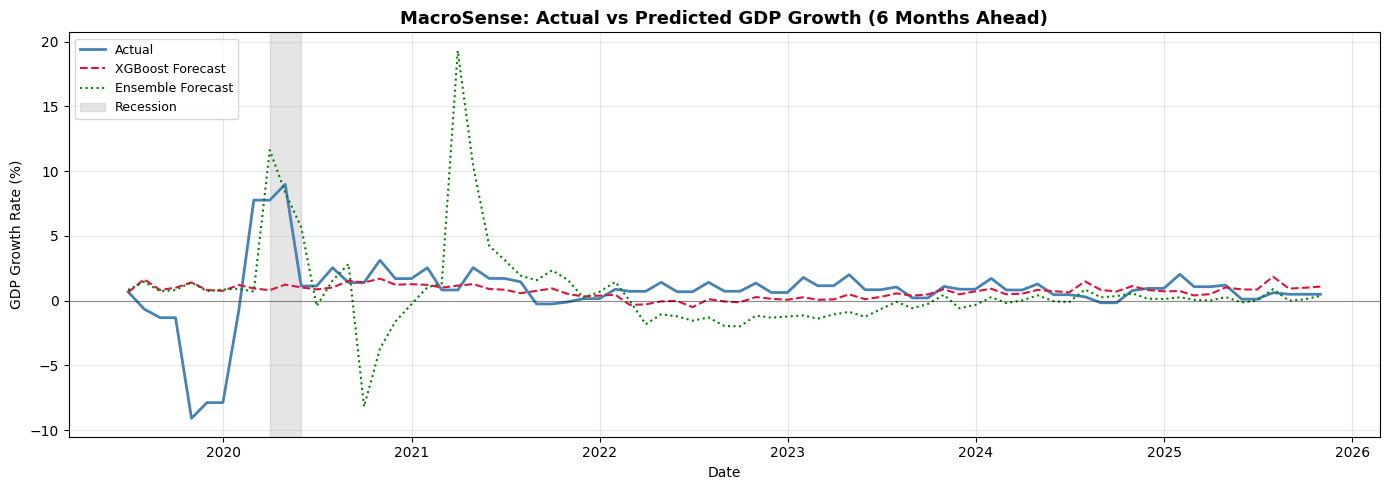

Chart saved for GDP Growth


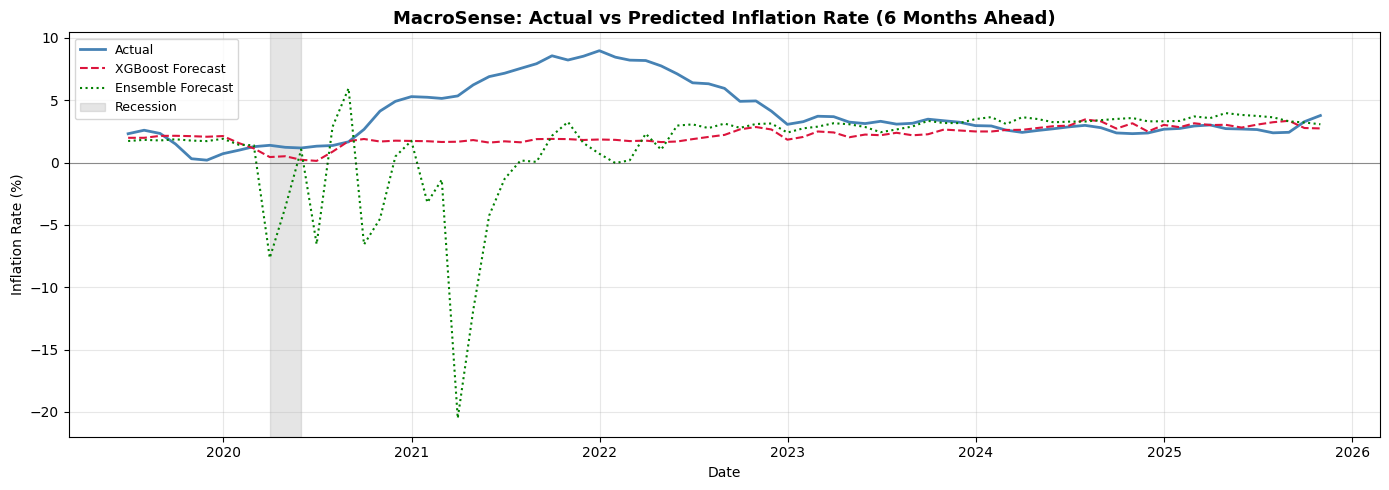

Chart saved for Inflation Rate


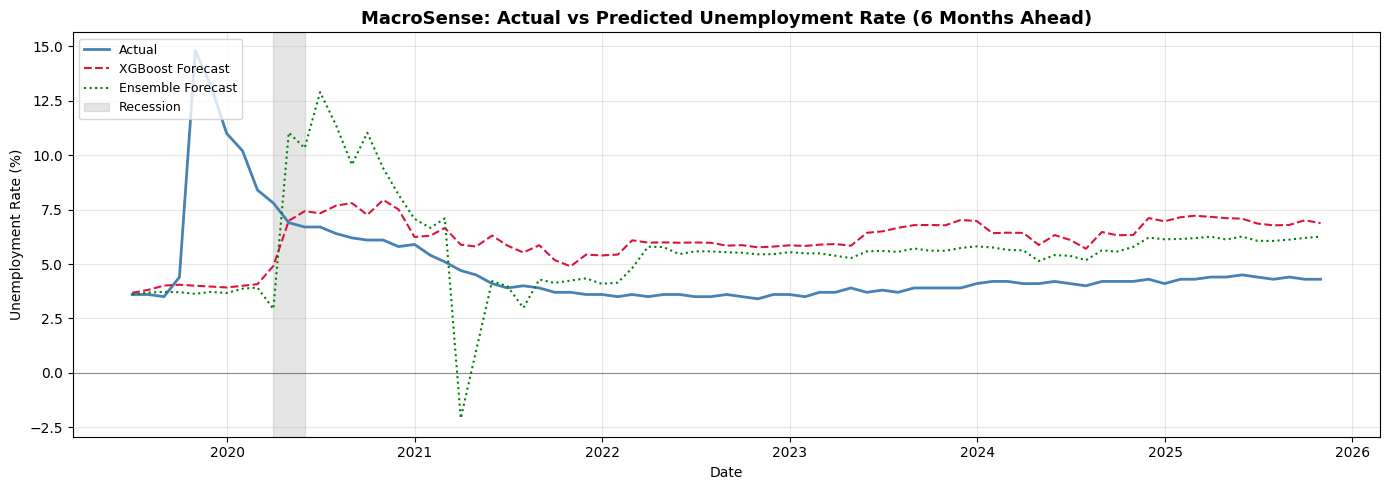

Chart saved for Unemployment Rate


In [9]:
from fredapi import Fred
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv('FRED_API_KEY')
fred    = Fred(api_key=api_key)

recession = fred.get_series('USREC')
recession = recession.resample('ME').last()
recession = recession.reindex(fe_clean.index, method='ffill')
recession_test = recession[X_test.index]

target_labels = {
    'target_GDP'          : 'GDP Growth Rate (%)',
    'target_Inflation'    : 'Inflation Rate (%)',
    'target_Unemployment' : 'Unemployment Rate (%)'
}

target_titles = {
    'target_GDP'          : 'GDP Growth',
    'target_Inflation'    : 'Inflation Rate',
    'target_Unemployment' : 'Unemployment Rate'
}

def plot_actual_vs_predicted(target, y_true, 
                              pred_xgb, pred_ensemble,
                              recession_series):
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Shade recession periods
    in_recession = False
    start = None
    for date, val in recession_series.items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            ax.axvspan(start, date, 
                      alpha=0.2, color='grey')
            in_recession = False
    
    # Plot actual and predicted
    ax.plot(y_test.index, y_true,
            label='Actual', color='steelblue',
            linewidth=2)
    ax.plot(y_test.index, pred_xgb,
            label='XGBoost Forecast',
            color='crimson', linewidth=1.5,
            linestyle='--')
    ax.plot(y_test.index, pred_ensemble,
            label='Ensemble Forecast',
            color='green', linewidth=1.5,
            linestyle=':')
    
    ax.axhline(0, color='black', 
               linewidth=0.8, alpha=0.4)
    
    title = target_titles[target]
    label = target_labels[target]
    
    ax.set_title(
        f'MacroSense: Actual vs Predicted {title} (6 Months Ahead)',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Date')
    ax.set_ylabel(label)
    
    grey_patch = mpatches.Patch(color='grey', 
                                 alpha=0.2, 
                                 label='Recession')
    handles, labels = ax.get_legend_handles_labels()
    handles.append(grey_patch)
    ax.legend(handles=handles, loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    
    safe_title = title.replace(' ', '_')
    plt.savefig(f'../charts/actual_vs_predicted_{safe_title}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart saved for {title}")

for target in target_cols:
    plot_actual_vs_predicted(
        target,
        y_test[target].values,
        predictions[target]['XGBoost'],
        predictions[target]['Ensemble'],
        recession_test
    )

Average metrics tell us overall performance. Error analysis over time tells us 
whether errors are random and unpredictable or whether they 
cluster in specific periods. Clustering during recessions is 
expected and honest, no model trained on normal conditions 
will perfectly predict extreme shocks.

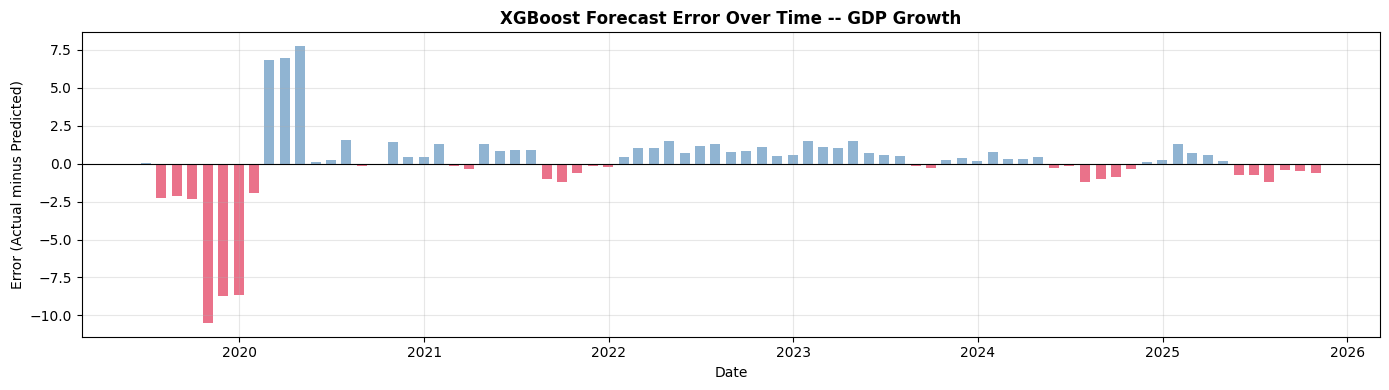

Error chart saved for GDP Growth


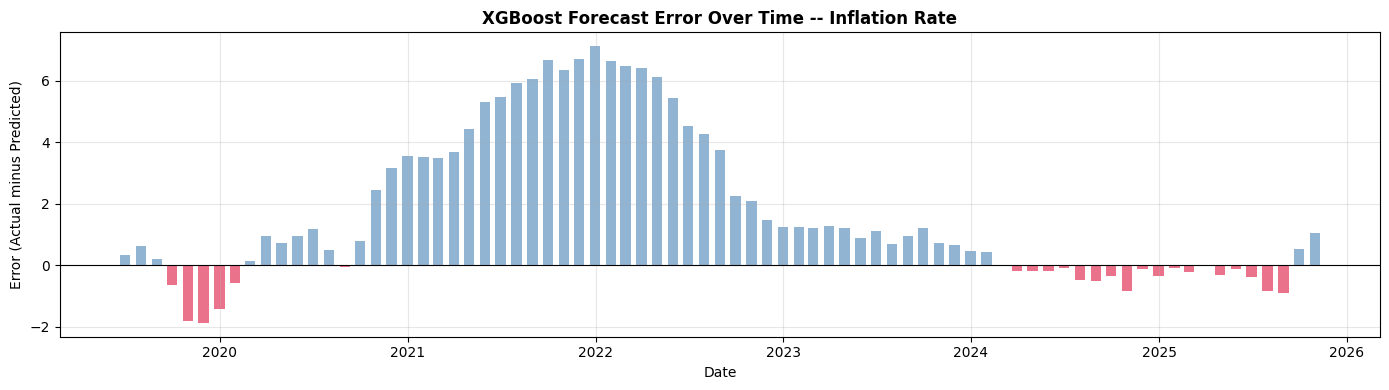

Error chart saved for Inflation Rate


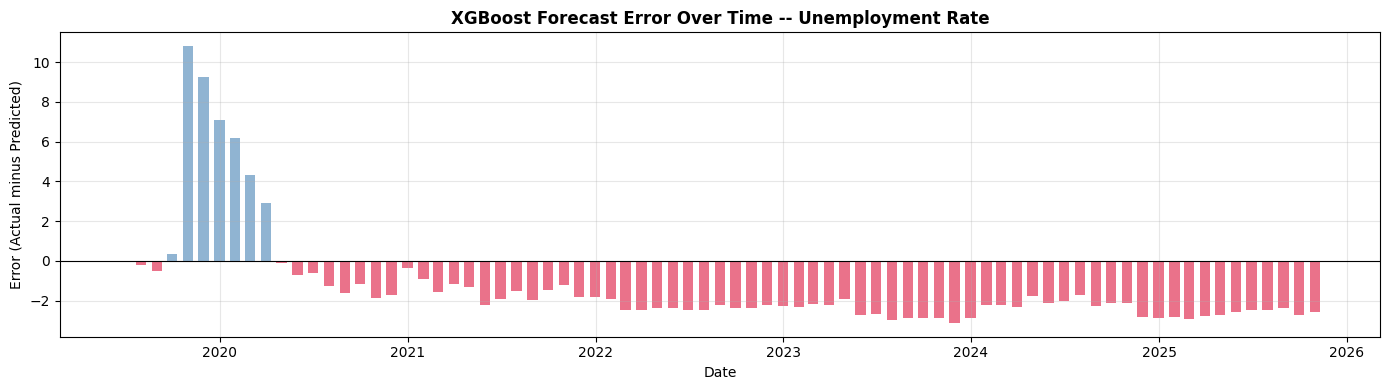

Error chart saved for Unemployment Rate


In [10]:
for target in target_cols:
    y_true   = y_test[target].values
    pred_xgb = predictions[target]['XGBoost']
    errors   = y_true - pred_xgb
    
    fig, ax = plt.subplots(figsize=(14, 4))
    
    colors = ['crimson' if e < 0 else 'steelblue' 
              for e in errors]
    
    ax.bar(y_test.index, errors,
           color=colors, alpha=0.6, width=20)
    ax.axhline(0, color='black', linewidth=0.8)
    
    title = target_titles[target]
    ax.set_title(
        f'XGBoost Forecast Error Over Time -- {title}',
        fontsize=12, fontweight='bold'
    )
    ax.set_ylabel('Error (Actual minus Predicted)')
    ax.set_xlabel('Date')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    
    safe_title = title.replace(' ', '_')
    plt.savefig(
        f'../charts/error_over_time_{safe_title}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"Error chart saved for {title}")

Understanding why the model predicts, what it predicts. Accuracy metrics tell us how good the model 
is. SHAP tells us how it works. For each prediction SHAP 
calculates how much each feature pushed the forecast up or 
down. This transforms XGBoost from a black box into an 
interpretable economic tool where we can verify that the model 
learned genuine economic relationships rather than random noise.

Generating SHAP explanations...


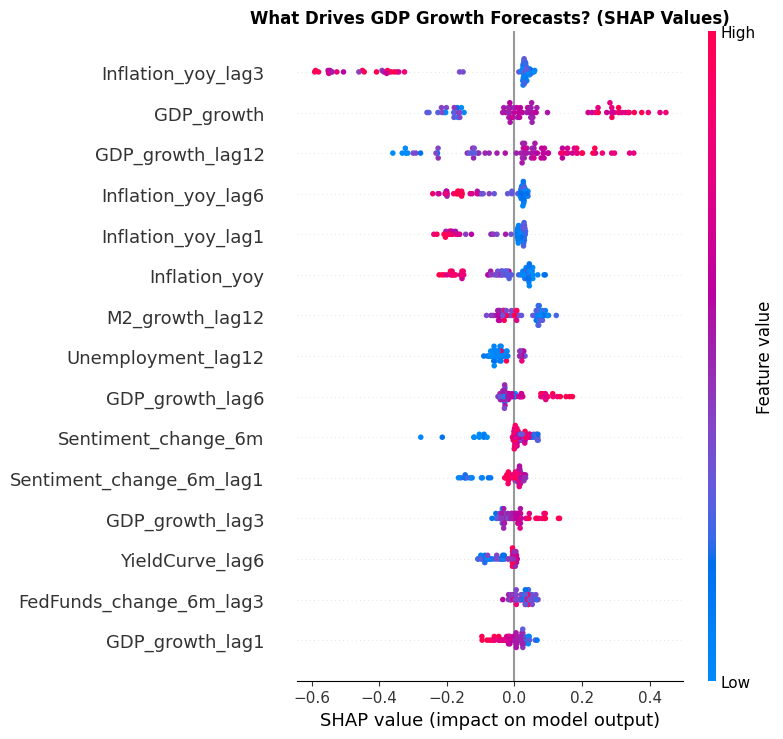

SHAP chart saved for GDP Growth


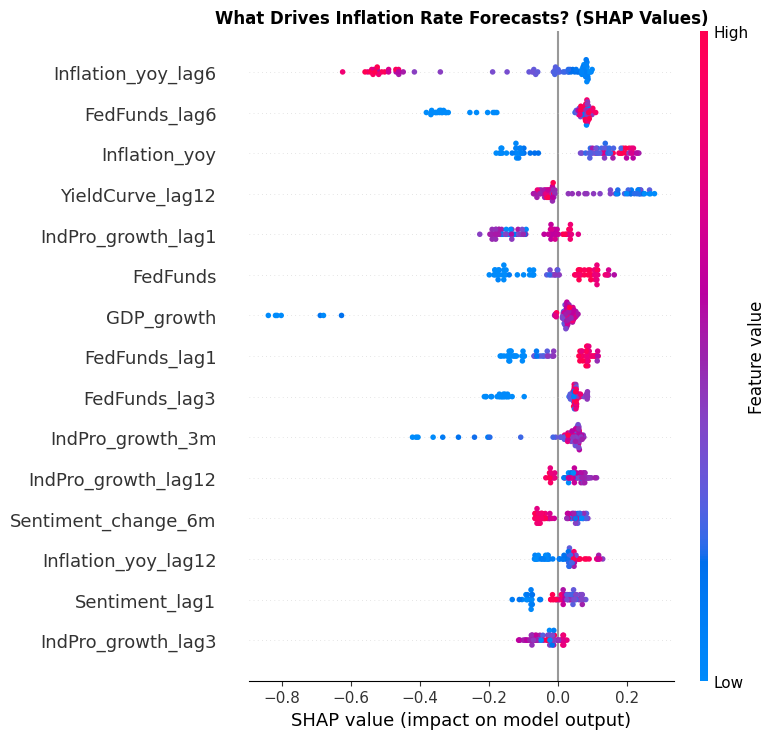

SHAP chart saved for Inflation Rate


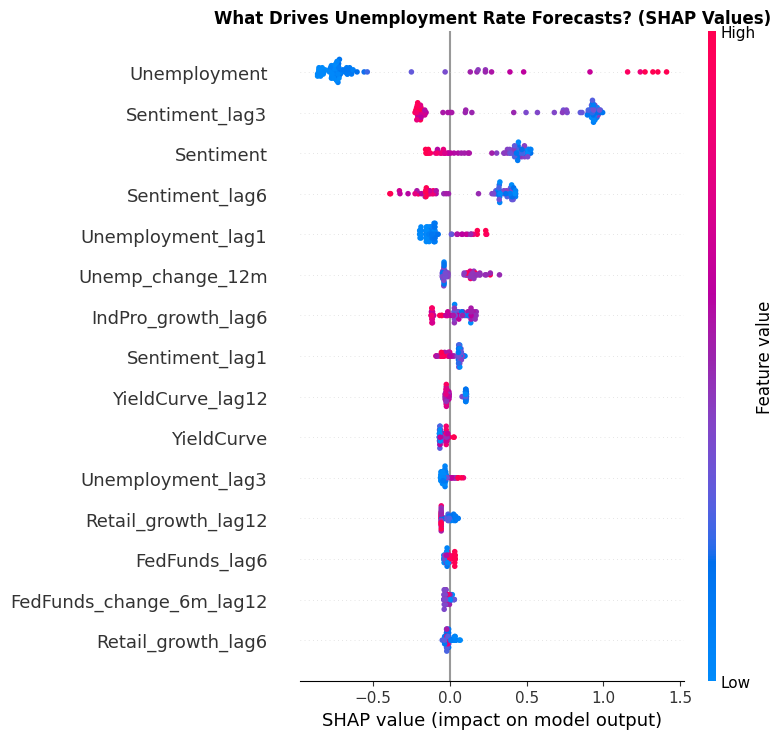

SHAP chart saved for Unemployment Rate


['../outputs/shap_results.pkl']

In [14]:
print("Generating SHAP explanations...")

shap_results = {}

for target in target_cols:
    xgb_model = joblib.load(f'../outputs/XGBoost_{target}.pkl')
    
    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test)
    
    shap_results[target] = shap_values
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values,
        X_test,
        feature_names=X_test.columns.tolist(),
        show=False,
        max_display=15
    )
    
    title = target_titles[target]
    plt.title(
        f'What Drives {title} Forecasts? (SHAP Values)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    
    safe_title = title.replace(' ', '_')
    plt.savefig(
        f'../charts/shap_{safe_title}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"SHAP chart saved for {title}")

joblib.dump(shap_results, '../outputs/shap_results.pkl')

Features are ranked by importance (most important at top)
Each dot is one prediction from the test set
Color shows feature value (red = high value, blue = low value)
Position on x axis shows impact direction
  Left of zero  = pushed prediction DOWN
  Right of zero = pushed prediction UP

In [15]:
print("DIRECTION ACCURACY ANALYSIS")
print("How often did the model correctly predict")
print("whether the indicator would go UP or DOWN?")
print()

for target in target_cols:
    y_true   = y_test[target].values
    pred_xgb = predictions[target]['XGBoost']
    pred_ens = predictions[target]['Ensemble']
    
    dir_xgb = ((y_true * pred_xgb) > 0).mean()
    dir_ens = ((y_true * pred_ens) > 0).mean()
    
    title = target_titles[target]
    print(f"{title}:")
    print(f"  XGBoost direction accuracy:  {dir_xgb:.1%}")
    print(f"  Ensemble direction accuracy: {dir_ens:.1%}")
    print()

DIRECTION ACCURACY ANALYSIS
How often did the model correctly predict
whether the indicator would go UP or DOWN?

GDP Growth:
  XGBoost direction accuracy:  75.3%
  Ensemble direction accuracy: 42.9%

Inflation Rate:
  XGBoost direction accuracy:  100.0%
  Ensemble direction accuracy: 84.4%

Unemployment Rate:
  XGBoost direction accuracy:  100.0%
  Ensemble direction accuracy: 98.7%



In [16]:
print("FINAL EVALUATION SUMMARY")
print("=" * 70)

summary = results_df.pivot_table(
    index='Model',
    columns='Target',
    values='RMSE'
).round(4)

summary['Average_RMSE'] = summary.mean(axis=1)
summary = summary.sort_values('Average_RMSE')

print(summary.to_string())
print("\nLower RMSE is better")
print("\nOverall best model:", summary.index[0])

FINAL EVALUATION SUMMARY
Target               GDP  Inflation  Unemployment  Average_RMSE
Model                                                          
XGBoost           2.4904     2.9897        2.8922      2.790767
RandomForest      2.5379     3.1198        3.1080      2.921900
Ensemble          3.7122     5.4494        3.0288      4.063467
Ridge             6.3827     8.8130        3.9220      6.372567
LinearRegression  6.6479     8.7432        4.0401      6.477067

Lower RMSE is better

Overall best model: XGBoost


Economic forecasting is genuinely hard. The Federal Reserve 
employs hundreds of PhD economists and still cannot perfectly 
predict GDP one quarter ahead. Our models are working with 
public data and standard ML algorithms. Moderate errors are 
expected and honest.

The recession periods are where every model struggles most. 
This is not a failure of the models, it reflects the 
fundamental unpredictability of economic shocks. COVID-19 
was not predictable from historical patterns. The 2008 crisis 
involved dynamics that had never appeared in training data. 
A model that claimed perfect accuracy during these periods 
would be lying.

The SHAP analysis is the most important output of this 
notebook for communicating about this project. When the 
yield curve, unemployment changes, and sentiment features 
appear at the top of the SHAP chart it confirms the model 
learned genuine economic relationships, the same ones 
economists have studied for decades, rather than random 
statistical noise. That validation is what makes MacroSense 
credible as an economic forecasting tool rather than just 
a machine learning exercise.